# Meta-analysis — PE-optimised balanced augmentation model

**Source run:** `cv_results/repnet_crosslead_deeper_multiseed_pe_2026-05-04_21-06-34/`  
**Best seed:** #49 (test AUROC=0.8205, AUPRC=0.4287)  
**Architecture:** RepNetCrossLeadDeeper, `stage_filters=(48, 96, 192)`, GAP feature dim = 192

Complement to `pe_model_analysis.ipynb`. That notebook covers training-curve, attention, saliency, Grad-CAM, and per-channel GAP voting. **This notebook** explores the model's representation space and decision distribution:

| § | Question |
|---|----------|
| 1 | Setup — load model + extract 192-d GAP embeddings (dev + test) |
| 2 | PCA — how low-dimensional is the 192-d embedding? Where do classes sit? |
| 3 | UMAP / t-SNE — non-linear structure |
| 4 | Bimodal `P(PE)` — fit GMMs to decompose the two visible modes per class |
| 5 | Clustering — does the model spontaneously group samples in embedding space? |
| 6 | Multi-seed predictive uncertainty per sample |
| 7 | Calibration — reliability, ECE, isotonic / Platt |
| 8 | Patient-level consistency (multiple recordings per patient) |
| 9 | Outliers — Mahalanobis distance, k-NN purity |
| 10 | Dev vs test embedding shift (covariate shift check) |
| 11 | Channel sparsity & informativeness |
| 12 | Synthesis |

## 1. Setup

In [103]:
import sys
from pathlib import Path
sys.path.insert(0, '../..')

import json
import warnings
import numpy as np
import pandas as pd
import torch
import plotly.io as pio
pio.renderers.default = "png"
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    silhouette_score, mutual_info_score, confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.neighbors import NearestNeighbors
from scipy import stats
from scipy.spatial.distance import cdist

from src.models.repnet_crosslead_deeper import RepNetCrossLeadDeeper
from src.data.dataset import load_seniordesign, split_holdout_grouped
from src.preprocessing.filters import BaselineWanderFilter, NotchFilter
from src.preprocessing.normalization import ZScoreNormalization

warnings.filterwarnings('ignore', category=UserWarning)

RUN_DIR    = Path('../../final_data/repnet_crosslead_deeper_multiseed_pe_2026-05-04_21-06-34')
DATA_DIR   = '../../data/seniordesign_upload'
SPLIT_SEED = 42
FS         = 250.0
LEADS      = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
C_NORM, C_PE = 'steelblue', 'tomato'

with open(RUN_DIR / 'config.json') as f:
    cfg = json.load(f)
NET_PARAMS = dict(
    stage_filters = tuple(cfg['params']['stage_filters']),
    kernels       = tuple(cfg['params']['kernels']),
    dropout       = cfg['params']['dropout'],
    n_heads       = cfg['params']['n_heads'],
)
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
print(f'Device: {device}')
print(f'Run:    {RUN_DIR.resolve()}')
print(f'Net params: {NET_PARAMS}')

Device: mps
Run:    /Users/ahmed/PycharmProjects/repnet/final_data/repnet_crosslead_deeper_multiseed_pe_2026-05-04_21-06-34
Net params: {'stage_filters': (48, 96, 192), 'kernels': (7, 5, 3), 'dropout': 0.0546, 'n_heads': 4}


In [104]:
net = RepNetCrossLeadDeeper(**NET_PARAMS).to(device)
net.load_state_dict(torch.load(RUN_DIR / 'best_model.pt', map_location=device))
net.eval()
n_params = sum(p.numel() for p in net.parameters())
results_json = json.load(open(RUN_DIR/'results.json'))
print(f'Loaded {n_params:,} params  |  best seed = {results_json["best_seed"]}  |  '
      f'reported test AUROC = {[r for r in results_json["per_seed"] if r["seed"]==results_json["best_seed"]][0]["auroc"]:.4f}')

Loaded 965,186 params  |  best seed = 49  |  reported test AUROC = 0.8205


In [105]:
X_raw, y_raw, patient_ids = load_seniordesign(DATA_DIR, return_patient_ids=True)

flat_mask = (X_raw.std(axis=2) < 1e-4).any(axis=1)
try:
    nan_mask = np.isnan(patient_ids.astype(float))
except (ValueError, TypeError):
    nan_mask = np.array([str(p).strip() in ('', 'nan', 'None') for p in patient_ids])
keep = ~flat_mask & ~nan_mask
X_raw, y_raw, patient_ids = X_raw[keep], y_raw[keep], patient_ids[keep]

X_proc, _ = BaselineWanderFilter(cutoff=0.5, order=4, fs=FS).transform(X_raw)
X_proc, _ = NotchFilter(freq=60.0, Q=30.0, fs=FS).transform(X_proc)
X_proc, _ = ZScoreNormalization(per_lead=True).transform(X_proc)

X_dev, X_test, y_dev, y_test, g_dev, g_test = split_holdout_grouped(
    X_proc, y_raw, patient_ids, test_size=0.20, seed=SPLIT_SEED,
)
print(f'Dev  : N={len(y_dev):4d}   PE={int(y_dev.sum()):3d}   Normal={int((y_dev==0).sum()):4d}')
print(f'Test : N={len(y_test):4d}   PE={int(y_test.sum()):3d}   Normal={int((y_test==0).sum()):4d}')

Dev  : N=1747   PE=277   Normal=1470
Test : N= 431   PE= 58   Normal= 373


In [106]:
def extract_gap_and_probs(net, X, device, batch_size=64):
    """One inference pass → (probs, 192-d GAP embeddings)."""
    bag = []
    def hook(_m, _i, o):
        bag.append(o.detach().cpu().squeeze(-1))   # (B, 192, 1) -> (B, 192)
    h = net.gap.register_forward_hook(hook)
    Xt = torch.tensor(X, dtype=torch.float32)
    dl = DataLoader(TensorDataset(Xt), batch_size=batch_size, num_workers=0)
    probs = []
    with torch.no_grad():
        for (xb,) in dl:
            logits = net(xb.to(device))
            probs.append(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
    h.remove()
    return np.concatenate(probs), torch.cat(bag, dim=0).numpy()

probs_dev,  emb_dev  = extract_gap_and_probs(net, X_dev,  device)
probs_test, emb_test = extract_gap_and_probs(net, X_test, device)
print(f'Embeddings — dev: {emb_dev.shape}   test: {emb_test.shape}')
print(f'Sanity     — best-seed test AUROC = {roc_auc_score(y_test, probs_test):.4f}  (expected ~0.8205)')

Embeddings — dev: (1747, 192)   test: (431, 192)
Sanity     — best-seed test AUROC = 0.8205  (expected ~0.8205)


In [107]:
npz = np.load(RUN_DIR / 'all_probs.npz', allow_pickle=True)
ms_probs = npz['probs']
ms_seeds = npz['seeds'] if 'seeds' in npz.files else np.array(cfg['training_seeds'])
probs_ensemble = ms_probs.mean(axis=0)
best_seed_idx  = int(np.where(ms_seeds == results_json['best_seed'])[0][0])
diff = np.abs(probs_test - ms_probs[best_seed_idx]).max()
print(f'multiseed probs : {ms_probs.shape}   max |best_model − seed{ms_seeds[best_seed_idx]}|  = {diff:.4g}')
print(f'Ensemble AUROC  : {roc_auc_score(y_test, probs_ensemble):.4f}   '
      f'AUPRC = {average_precision_score(y_test, probs_ensemble):.4f}')

tau   = 0.5
pred  = (probs_test >= tau).astype(int)
categ = np.where((y_test==1)&(pred==1), 'TP',
        np.where((y_test==0)&(pred==0), 'TN',
        np.where((y_test==0)&(pred==1), 'FP', 'FN')))
categ_color = {'TP': 'tomato', 'TN': 'steelblue', 'FP': 'orange', 'FN': 'purple'}
print('\nConfusion (τ=0.5):')
print(pd.crosstab(pd.Series(y_test, name='true'), pd.Series(pred, name='pred'), margins=True))

multiseed probs : (30, 431)   max |best_model − seed49|  = 7.686e-05
Ensemble AUROC  : 0.8167   AUPRC = 0.3826

Confusion (τ=0.5):
pred    0    1  All
true               
0     284   89  373
1      18   40   58
All   302  129  431


## 2. PCA on 192-d GAP embeddings (test set)

How low-dimensional is the embedding? How linearly separable are Normal vs PE in this space?

Variance — first 5 PCs: [0.399 0.287 0.096 0.062 0.034]
k for 95% var = 10   k for 99% var = 31   (out of 192)


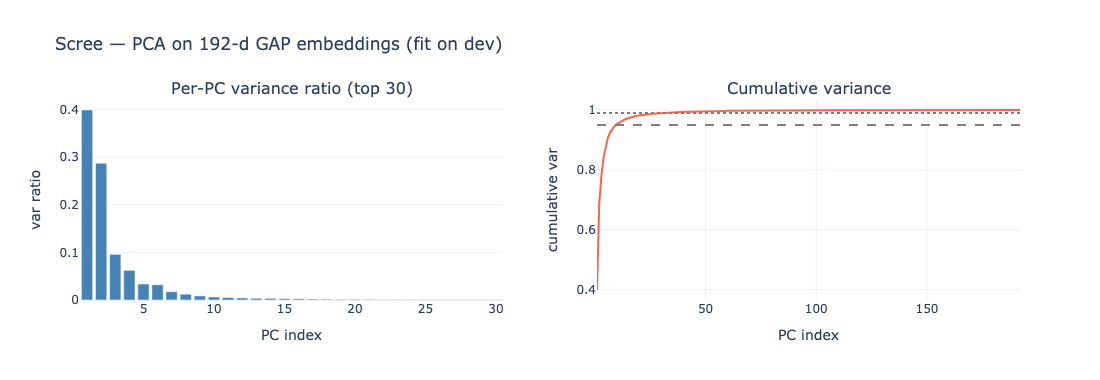

In [108]:
scaler   = StandardScaler().fit(emb_dev)         # fit on dev to avoid leakage
emb_devZ = scaler.transform(emb_dev)
emb_teZ  = scaler.transform(emb_test)

pca = PCA(n_components=min(192, emb_devZ.shape[0])).fit(emb_devZ)
pcs_test = pca.transform(emb_teZ)
pcs_dev  = pca.transform(emb_devZ)

var_ratio = pca.explained_variance_ratio_
cum       = np.cumsum(var_ratio)
k95       = int(np.searchsorted(cum, 0.95) + 1)
k99       = int(np.searchsorted(cum, 0.99) + 1)
print(f'Variance — first 5 PCs: {var_ratio[:5].round(3)}')
print(f'k for 95% var = {k95}   k for 99% var = {k99}   (out of {len(var_ratio)})')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Per-PC variance ratio (top 30)', 'Cumulative variance'))
fig.add_trace(go.Bar(x=np.arange(1, 31), y=var_ratio[:30], marker_color='steelblue', showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=np.arange(1, len(cum)+1), y=cum, mode='lines', line=dict(color='tomato'), showlegend=False), row=1, col=2)
fig.add_hline(y=0.95, line=dict(dash='dash', color='gray'), row=1, col=2)
fig.add_hline(y=0.99, line=dict(dash='dot',  color='gray'), row=1, col=2)
fig.update_xaxes(title_text='PC index', row=1, col=1); fig.update_yaxes(title_text='var ratio', row=1, col=1)
fig.update_xaxes(title_text='PC index', row=1, col=2); fig.update_yaxes(title_text='cumulative var', row=1, col=2)
fig.update_layout(template='plotly_white', width=1100, height=380, title='Scree — PCA on 192-d GAP embeddings (fit on dev)')
fig.show()

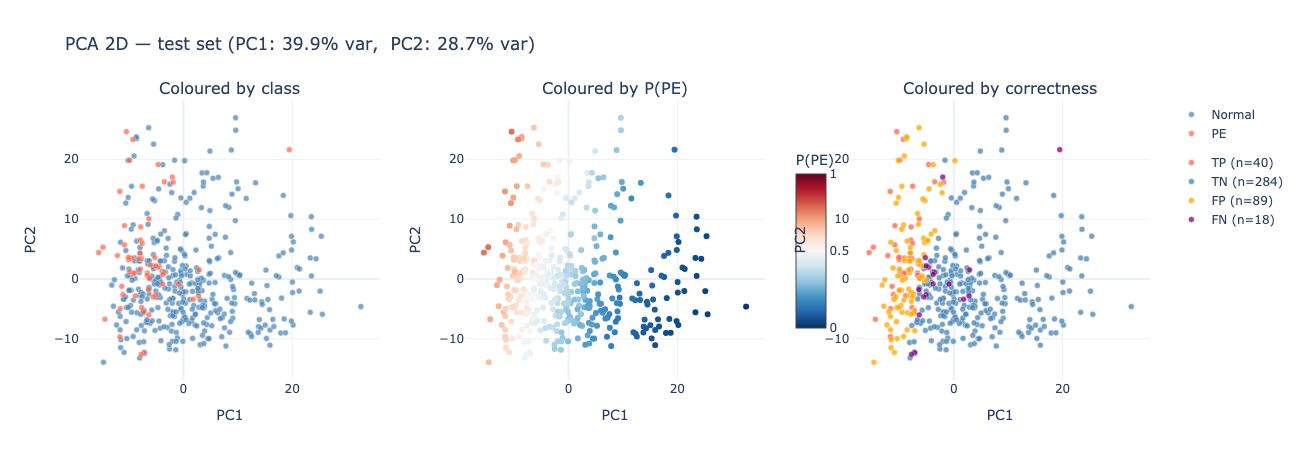

In [109]:
df_pca = pd.DataFrame({
    'PC1': pcs_test[:, 0], 'PC2': pcs_test[:, 1], 'PC3': pcs_test[:, 2],
    'class': np.where(y_test==1, 'PE', 'Normal'),
    'P(PE)': probs_test, 'category': categ,
    'patient': g_test,
})

fig = make_subplots(rows=1, cols=3,
    subplot_titles=('Coloured by class', 'Coloured by P(PE)', 'Coloured by correctness'),
    horizontal_spacing=0.08)
for cls, c in [('Normal', C_NORM), ('PE', C_PE)]:
    sub = df_pca[df_pca['class']==cls]
    fig.add_trace(go.Scatter(x=sub.PC1, y=sub.PC2, mode='markers',
        marker=dict(size=6, color=c, opacity=0.7, line=dict(width=0.5, color='white')),
        name=cls, legendgroup='cls'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_pca.PC1, y=df_pca.PC2, mode='markers',
    marker=dict(size=6, color=df_pca['P(PE)'], colorscale='RdBu_r', cmin=0, cmax=1,
                showscale=True, colorbar=dict(title='P(PE)', x=0.66, len=0.7)),
    showlegend=False), row=1, col=2)
for cat, c in categ_color.items():
    sub = df_pca[df_pca['category']==cat]
    if len(sub):
        fig.add_trace(go.Scatter(x=sub.PC1, y=sub.PC2, mode='markers',
            marker=dict(size=6, color=c, opacity=0.75, line=dict(width=0.5, color='white')),
            name=f'{cat} (n={len(sub)})', legendgroup='cat'), row=1, col=3)
fig.update_xaxes(title_text='PC1'); fig.update_yaxes(title_text='PC2')
fig.update_layout(template='plotly_white', width=1300, height=460,
    title=f'PCA 2D — test set (PC1: {var_ratio[0]*100:.1f}% var,  PC2: {var_ratio[1]*100:.1f}% var)')
fig.show()

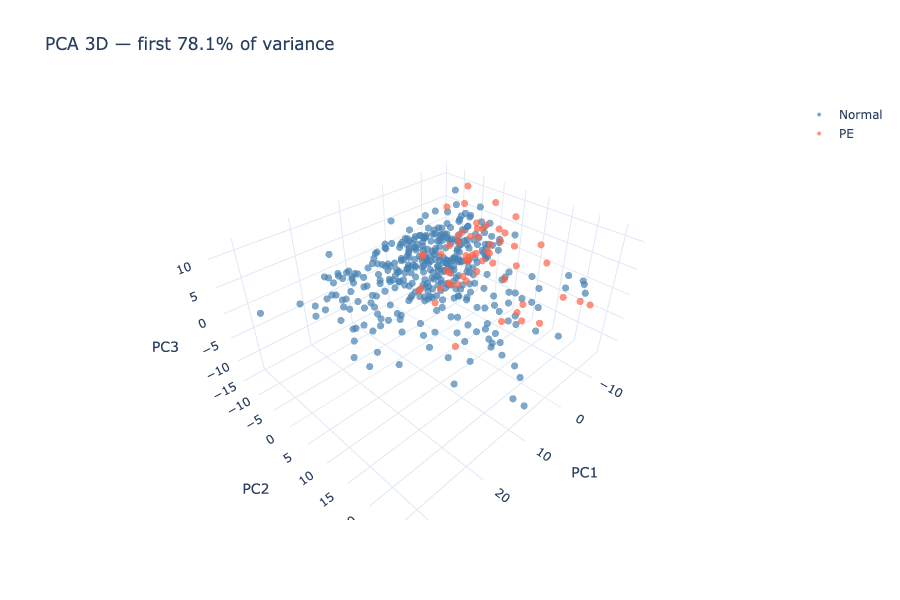

In [110]:
fig = go.Figure()
for cls, c in [('Normal', C_NORM), ('PE', C_PE)]:
    sub = df_pca[df_pca['class']==cls]
    fig.add_trace(go.Scatter3d(x=sub.PC1, y=sub.PC2, z=sub.PC3, mode='markers',
        marker=dict(size=4, color=c, opacity=0.7), name=cls,
        text=[f'P(PE)={p:.2f}<br>{cat}' for p, cat in zip(sub['P(PE)'], sub['category'])]))
fig.update_layout(template='plotly_white', width=900, height=600,
    title=f'PCA 3D — first {var_ratio[:3].sum()*100:.1f}% of variance',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'))
fig.show()

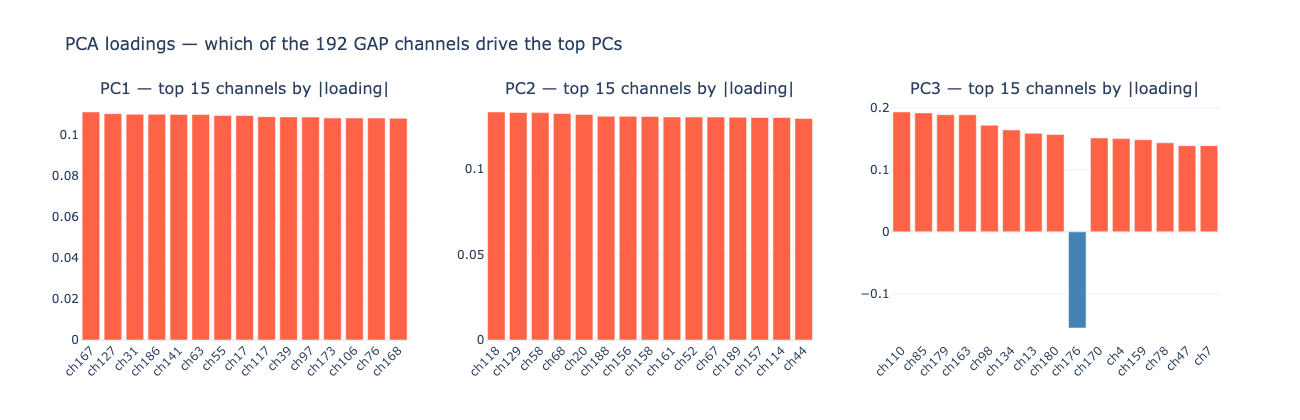

In [111]:
# Top channels driving PC1, PC2, PC3.
loadings = pca.components_[:3]                # (3, 192)
top_k = 15
fig = make_subplots(rows=1, cols=3, subplot_titles=[f'PC{i+1} — top {top_k} channels by |loading|' for i in range(3)])
for i in range(3):
    idx = np.argsort(-np.abs(loadings[i]))[:top_k]
    vals = loadings[i, idx]
    colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
    fig.add_trace(go.Bar(x=[f'ch{c}' for c in idx], y=vals, marker_color=colors, showlegend=False), row=1, col=i+1)
    fig.update_xaxes(tickangle=-45, row=1, col=i+1)
fig.update_layout(template='plotly_white', width=1300, height=420,
    title='PCA loadings — which of the 192 GAP channels drive the top PCs')
fig.show()

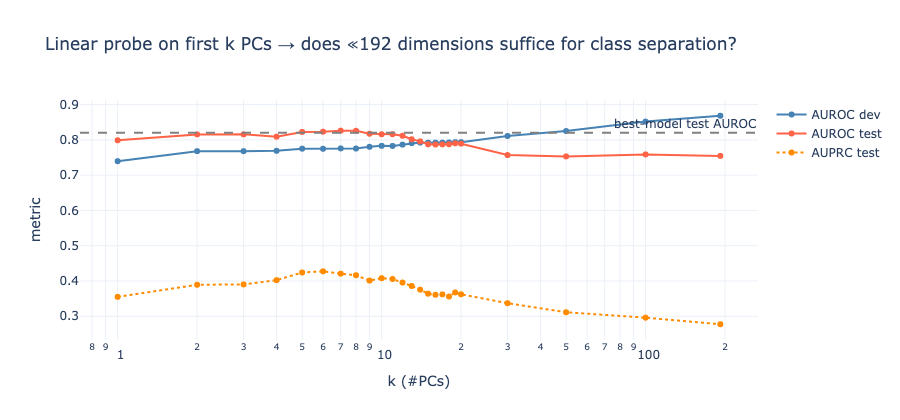

,k,AUROC_dev,AUROC_test,AUPRC_test
0,1,0.739613,0.798789,0.354869
1,2,0.767978,0.815476,0.389226
2,3,0.767958,0.815614,0.390180
3,4,0.769012,0.808958,0.402300
4,5,0.775004,0.822455,0.423978
5,6,0.774761,0.823195,0.427338
6,7,0.775709,0.825968,0.420649
7,8,0.775459,0.825737,0.416153
8,9,0.780348,0.817417,0.401003
9,10,0.783035,0.815892,0.407830


In [112]:
# Linear probing: how many PCs are enough to recover the model's classification?
ks = list(range(1, 21)) + [30, 50, 100, 192]
ks = [k for k in ks if k <= pcs_dev.shape[1]]
rows = []
for k in ks:
    clf = LogisticRegression(max_iter=2000, C=1.0).fit(pcs_dev[:, :k], y_dev)
    p_dev  = clf.predict_proba(pcs_dev[:,  :k])[:, 1]
    p_test = clf.predict_proba(pcs_test[:, :k])[:, 1]
    rows.append({'k': k,
        'AUROC_dev': roc_auc_score(y_dev,  p_dev),
        'AUROC_test': roc_auc_score(y_test, p_test),
        'AUPRC_test': average_precision_score(y_test, p_test)})
df_probe = pd.DataFrame(rows)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_probe.k, y=df_probe.AUROC_dev,  mode='lines+markers', name='AUROC dev',
    line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=df_probe.k, y=df_probe.AUROC_test, mode='lines+markers', name='AUROC test',
    line=dict(color='tomato')))
fig.add_trace(go.Scatter(x=df_probe.k, y=df_probe.AUPRC_test, mode='lines+markers', name='AUPRC test',
    line=dict(color='darkorange', dash='dot')))
fig.add_hline(y=roc_auc_score(y_test, probs_test), line=dict(dash='dash', color='gray'),
              annotation_text='best-model test AUROC')
fig.update_layout(template='plotly_white', width=900, height=420,
    title='Linear probe on first k PCs → does ≪192 dimensions suffice for class separation?',
    xaxis=dict(title='k (#PCs)', type='log'), yaxis_title='metric')
fig.show()
df_probe

## 3. Non-linear projection — UMAP / t-SNE

Look for structure that PCA misses (manifolds, sub-clusters).

In [113]:
try:
    import umap
    have_umap = True
except ImportError:
    have_umap = False
    print('umap-learn not installed — skipping UMAP.  pip install umap-learn  to enable.')

if have_umap:
    reducer_um = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    emb2_um    = reducer_um.fit_transform(emb_teZ)
else:
    emb2_um = None

tsne     = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, learning_rate='auto')
emb2_tsne = tsne.fit_transform(emb_teZ)
print(f'UMAP shape : {None if emb2_um is None else emb2_um.shape}    t-SNE shape : {emb2_tsne.shape}')

umap-learn not installed — skipping UMAP.  pip install umap-learn  to enable.
UMAP shape : None    t-SNE shape : (431, 2)


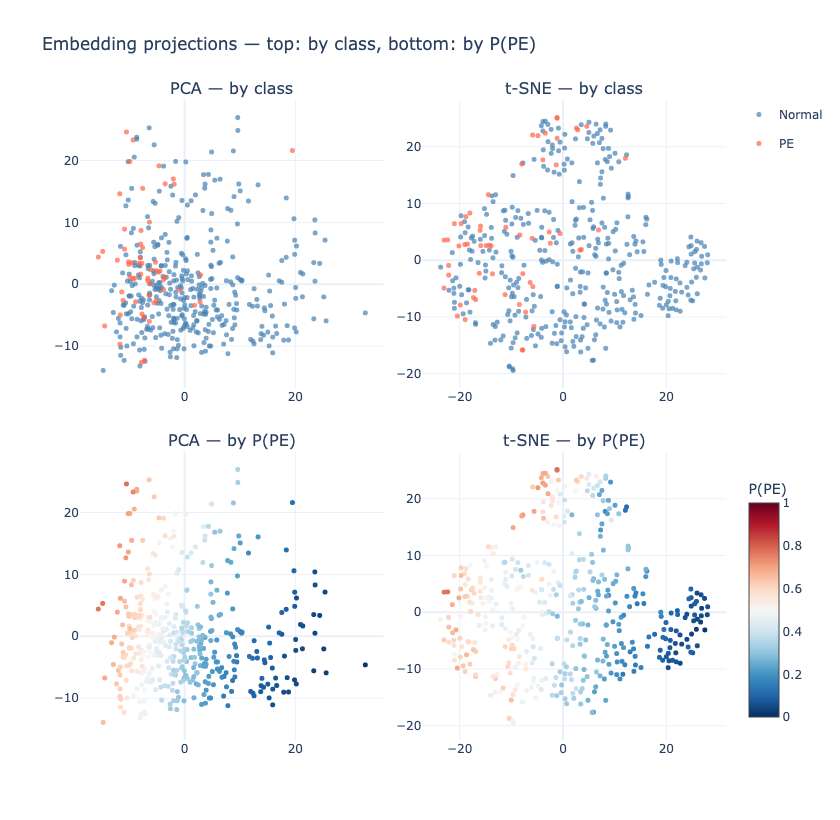

In [114]:
panels = []
panels.append(('PCA',   pcs_test[:, :2]))
if emb2_um is not None:
    panels.append(('UMAP',  emb2_um))
panels.append(('t-SNE', emb2_tsne))

fig = make_subplots(rows=2, cols=len(panels),
    subplot_titles=[f'{n} — by class' for n,_ in panels] + [f'{n} — by P(PE)' for n,_ in panels],
    horizontal_spacing=0.06, vertical_spacing=0.10)
for col, (name, emb2) in enumerate(panels, start=1):
    for cls, c in [('Normal', C_NORM), ('PE', C_PE)]:
        m = (np.array(['Normal' if y==0 else 'PE' for y in y_test])==cls)
        fig.add_trace(go.Scatter(x=emb2[m,0], y=emb2[m,1], mode='markers',
            marker=dict(size=5, color=c, opacity=0.7),
            name=cls, legendgroup=cls, showlegend=(col==1)), row=1, col=col)
    fig.add_trace(go.Scatter(x=emb2[:,0], y=emb2[:,1], mode='markers',
        marker=dict(size=5, color=probs_test, colorscale='RdBu_r', cmin=0, cmax=1,
                    showscale=(col==len(panels)),
                    colorbar=dict(title='P(PE)', x=1.02, len=0.4, y=0.22)),
        showlegend=False), row=2, col=col)
fig.update_layout(template='plotly_white', width=420*len(panels), height=820,
    title='Embedding projections — top: by class, bottom: by P(PE)')
fig.show()

## 4. Bimodal P(PE) decomposition

The test-set P(PE) histogram visibly contains **two mode-like Normal distributions** within each class. Fit Gaussian mixtures to make those modes explicit, then characterize what differs between them.

In [115]:
def fit_gmm_1d(p, K=2, seed=0):
    g = GaussianMixture(n_components=K, covariance_type='full', random_state=seed,
                        n_init=10, max_iter=500).fit(p.reshape(-1, 1))
    order = np.argsort(g.means_.ravel())
    return dict(
        weights = g.weights_[order],
        means   = g.means_.ravel()[order],
        stds    = np.sqrt(g.covariances_.ravel()[order]),
        gmm     = g, order = order,
    )

g_norm = fit_gmm_1d(probs_test[y_test==0], K=2)
g_pe   = fit_gmm_1d(probs_test[y_test==1], K=2)
print('Normals (n=%d) — 2-component GMM on P(PE):' % int((y_test==0).sum()))
for i in range(2):
    print(f'  comp {i}: w={g_norm["weights"][i]:.3f}  μ={g_norm["means"][i]:.3f}  σ={g_norm["stds"][i]:.3f}')
print('PE      (n=%d) — 2-component GMM on P(PE):' % int((y_test==1).sum()))
for i in range(2):
    print(f'  comp {i}: w={g_pe["weights"][i]:.3f}  μ={g_pe["means"][i]:.3f}  σ={g_pe["stds"][i]:.3f}')

Normals (n=373) — 2-component GMM on P(PE):
  comp 0: w=0.531  μ=0.220  σ=0.114
  comp 1: w=0.469  μ=0.499  σ=0.106
PE      (n=58) — 2-component GMM on P(PE):
  comp 0: w=0.071  μ=0.268  σ=0.094
  comp 1: w=0.929  μ=0.578  σ=0.094


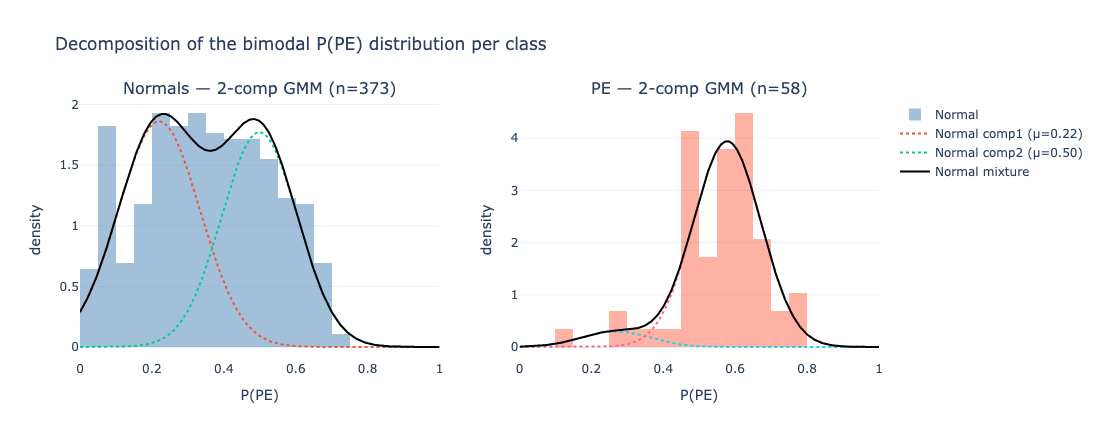

In [116]:
xx = np.linspace(0, 1, 400)
fig = make_subplots(rows=1, cols=2,
    subplot_titles=(f'Normals — 2-comp GMM (n={int((y_test==0).sum())})',
                    f'PE — 2-comp GMM (n={int((y_test==1).sum())})'))
for col, (g, label, color) in enumerate([(g_norm, 'Normal', C_NORM), (g_pe, 'PE', C_PE)], start=1):
    p_data = probs_test[y_test==(0 if label=='Normal' else 1)]
    fig.add_trace(go.Histogram(x=p_data, histnorm='probability density', nbinsx=30,
        marker_color=color, opacity=0.5, name=label, showlegend=(col==1)), row=1, col=col)
    total = np.zeros_like(xx)
    for i in range(2):
        comp = g['weights'][i] * stats.norm.pdf(xx, g['means'][i], g['stds'][i])
        total += comp
        fig.add_trace(go.Scatter(x=xx, y=comp, mode='lines', line=dict(width=2, dash='dot'),
            name=f'{label} comp{i+1} (μ={g["means"][i]:.2f})', showlegend=(col==1)), row=1, col=col)
    fig.add_trace(go.Scatter(x=xx, y=total, mode='lines', line=dict(color='black', width=2),
        name=f'{label} mixture', showlegend=(col==1)), row=1, col=col)
fig.update_xaxes(title='P(PE)'); fig.update_yaxes(title='density')
fig.update_layout(template='plotly_white', width=1100, height=440, barmode='overlay',
    title='Decomposition of the bimodal P(PE) distribution per class')
fig.show()

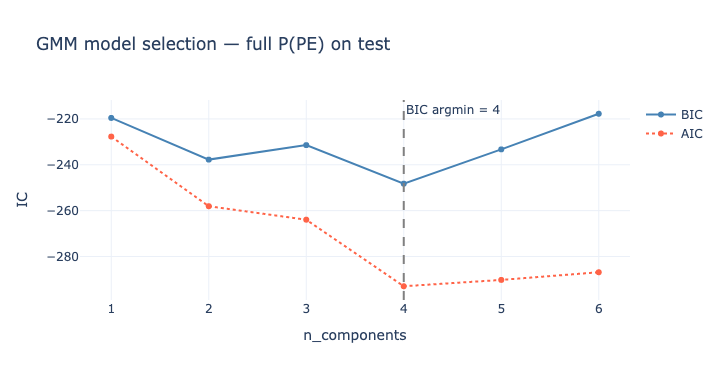

,K,BIC,AIC
0,1,-219.569317,-227.701533
1,2,-237.741046,-258.071587
2,3,-231.421337,-263.950202
3,4,-248.243309,-292.970498
4,5,-233.283776,-290.209289
5,6,-217.741756,-286.865594


In [117]:
# BIC sweep on full P(PE) — does the data prefer ≥2 components?
rows = []
for K in range(1, 7):
    g = GaussianMixture(n_components=K, n_init=5, random_state=0).fit(probs_test.reshape(-1, 1))
    rows.append({'K': K, 'BIC': g.bic(probs_test.reshape(-1, 1)),
                 'AIC': g.aic(probs_test.reshape(-1, 1))})
df_bic = pd.DataFrame(rows)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_bic.K, y=df_bic.BIC, mode='lines+markers', name='BIC', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=df_bic.K, y=df_bic.AIC, mode='lines+markers', name='AIC', line=dict(color='tomato', dash='dot')))
fig.add_vline(x=df_bic.loc[df_bic.BIC.idxmin(), 'K'], line=dict(dash='dash', color='gray'),
              annotation_text=f'BIC argmin = {df_bic.loc[df_bic.BIC.idxmin(), "K"]}')
fig.update_layout(template='plotly_white', width=720, height=380,
    title='GMM model selection — full P(PE) on test', xaxis_title='n_components', yaxis_title='IC')
fig.show()
df_bic

In [118]:
# Assign each test sample to a mode (per-class GMM) and characterize the four buckets.
def assign_modes(p, g):
    return g['gmm'].predict(p.reshape(-1, 1))

comp_norm = np.full(len(y_test), -1)
comp_pe   = np.full(len(y_test), -1)
comp_norm[y_test==0] = assign_modes(probs_test[y_test==0], g_norm)
comp_pe  [y_test==1] = assign_modes(probs_test[y_test==1], g_pe)

def remap_to_sorted(c, g):
    inv = np.argsort(g['order']); return inv[c]
comp_norm[y_test==0] = remap_to_sorted(comp_norm[y_test==0], g_norm)
comp_pe  [y_test==1] = remap_to_sorted(comp_pe  [y_test==1], g_pe)

bucket = np.where(y_test==0,
                  np.where(comp_norm==0, 'Normal-low', 'Normal-high'),
                  np.where(comp_pe  ==0, 'PE-low',     'PE-high'))

# Lead-wise signal stats per bucket
rms      = np.sqrt(np.mean(X_test**2, axis=2)).mean(axis=1)
peak_med = np.median(np.abs(X_test).max(axis=2), axis=1)
hf_noise = np.std(np.diff(X_test, axis=2), axis=(1,2))

def safe_pca_centroid(emb, mask):
    if mask.sum() == 0: return [np.nan]*3
    return pca.transform(scaler.transform(emb[mask]))[:, :3].mean(axis=0).tolist()

summary_rows = []
for label in ['Normal-low', 'Normal-high', 'PE-low', 'PE-high']:
    mask = (bucket == label)
    if mask.sum() == 0:
        continue
    cen = safe_pca_centroid(emb_test, mask)
    summary_rows.append({
        'mode': label, 'n': int(mask.sum()),
        'mean P(PE)': float(probs_test[mask].mean()),
        'std P(PE)' : float(probs_test[mask].std()),
        'mean RMS'  : float(rms[mask].mean()),
        'mean peak' : float(peak_med[mask].mean()),
        'HF noise'  : float(hf_noise[mask].mean()),
        'PC1' : round(cen[0], 3), 'PC2': round(cen[1], 3), 'PC3': round(cen[2], 3),
    })
df_modes = pd.DataFrame(summary_rows)
df_modes

,mode,n,mean P(PE),std P(PE),mean RMS,mean peak,HF noise,PC1,PC2,PC3
0,Normal-low,202,0.213537,0.101405,1.0,6.457124,0.242873,7.588,-1.624,0.041
1,Normal-high,171,0.513156,0.089237,1.0,6.168960,0.231035,-5.839,1.422,0.380
2,PE-low,4,0.251037,0.074113,1.0,5.575648,0.243055,6.752,4.221,-1.951
3,PE-high,54,0.578428,0.092216,1.0,6.245738,0.224860,-7.849,3.507,1.079


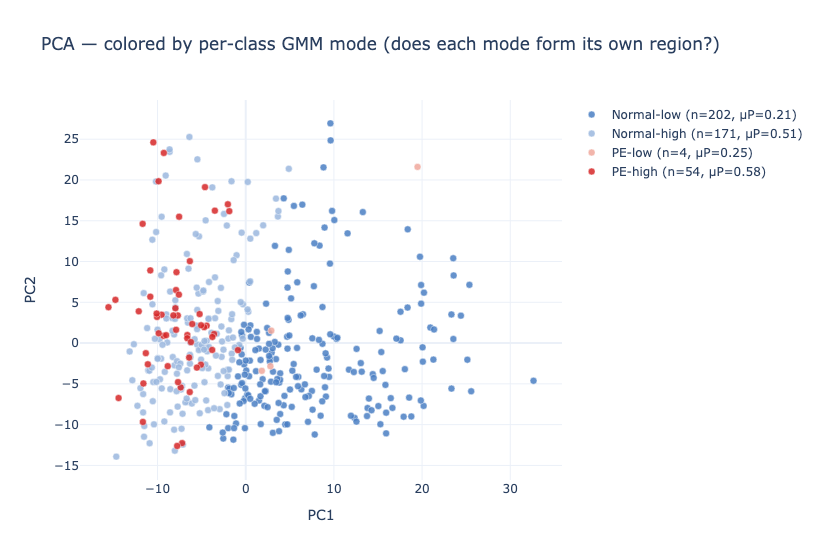

In [119]:
bucket_color = {'Normal-low': '#4a7fc4', 'Normal-high': '#9bb8df',
                'PE-low': '#f0a89c',     'PE-high': '#d62728'}
df_pca['mode'] = bucket
fig = go.Figure()
for label, c in bucket_color.items():
    sub = df_pca[df_pca['mode']==label]
    if len(sub):
        fig.add_trace(go.Scatter(x=sub.PC1, y=sub.PC2, mode='markers',
            marker=dict(size=7, color=c, opacity=0.85, line=dict(width=0.5, color='white')),
            name=f'{label} (n={len(sub)}, μP={sub["P(PE)"].mean():.2f})'))
fig.update_layout(template='plotly_white', width=820, height=560,
    title='PCA — colored by per-class GMM mode (does each mode form its own region?)',
    xaxis_title='PC1', yaxis_title='PC2')
fig.show()

## 5. Cluster analysis on 192-d embeddings

Independent of labels — does the embedding space spontaneously cluster?

In [120]:
rows = []
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(emb_teZ)
    sil = silhouette_score(emb_teZ, km.labels_) if k > 1 else np.nan
    ari = mutual_info_score(y_test, km.labels_)
    rows.append({'k': k, 'silhouette': round(sil, 3), 'MI(y, cluster)': round(ari, 3),
                 'inertia': round(km.inertia_, 1)})
df_km = pd.DataFrame(rows)
print(df_km.to_string(index=False))

km2 = KMeans(n_clusters=2, n_init=10, random_state=0).fit(emb_teZ)
print('\nKMeans k=2 vs class:')
print(pd.crosstab(pd.Series(y_test, name='true'), pd.Series(km2.labels_, name='cluster'), margins=True))
print('\nKMeans k=2 vs P(PE) bucket:')
print(pd.crosstab(pd.Series(bucket, name='mode'), pd.Series(km2.labels_, name='cluster'), margins=True))

 k  silhouette  MI(y, cluster)  inertia
 2       0.288           0.039  65951.6
 3       0.306           0.034  49945.3
 4       0.205           0.064  43443.2
 5       0.190           0.059  39417.1

KMeans k=2 vs class:
cluster    0    1  All
true                  
0        122  251  373
1          1   57   58
All      123  308  431

KMeans k=2 vs P(PE) bucket:
cluster        0    1  All
mode                      
Normal-high    5  166  171
Normal-low   117   85  202
PE-high        0   54   54
PE-low         1    3    4
All          123  308  431


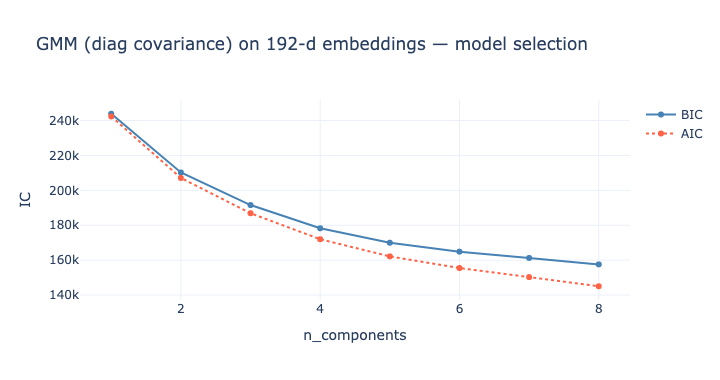

,K,BIC,AIC,log_lik_per_sample
0,1,243870.976876,242309.591370,-280.210663
1,2,210209.405298,207082.568176,-238.450775
2,3,191562.977731,186870.688995,-214.109848
3,4,178243.519709,171985.779358,-195.948700
4,5,169967.503519,162144.311554,-183.638412
5,6,164866.113795,155477.470215,-175.010986
6,7,161242.156505,150288.061310,-168.097519
7,8,157556.800655,145037.253845,-161.112823


In [121]:
# GMM in embedding space — model selection over n_components.
rows = []
for K in range(1, 9):
    g = GaussianMixture(n_components=K, covariance_type='diag', n_init=3,
                        random_state=0, max_iter=300).fit(emb_teZ)
    rows.append({'K': K, 'BIC': g.bic(emb_teZ), 'AIC': g.aic(emb_teZ),
                 'log_lik_per_sample': g.score(emb_teZ)})
df_gmm = pd.DataFrame(rows)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_gmm.K, y=df_gmm.BIC, mode='lines+markers', name='BIC', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=df_gmm.K, y=df_gmm.AIC, mode='lines+markers', name='AIC', line=dict(color='tomato', dash='dot')))
fig.update_layout(template='plotly_white', width=720, height=380,
    title='GMM (diag covariance) on 192-d embeddings — model selection',
    xaxis_title='n_components', yaxis_title='IC')
fig.show()
df_gmm

## 6. Multi-seed predictive uncertainty

30 independently-trained models give 30 probabilities per test sample. Spread across seeds approximates **epistemic uncertainty** at that input.

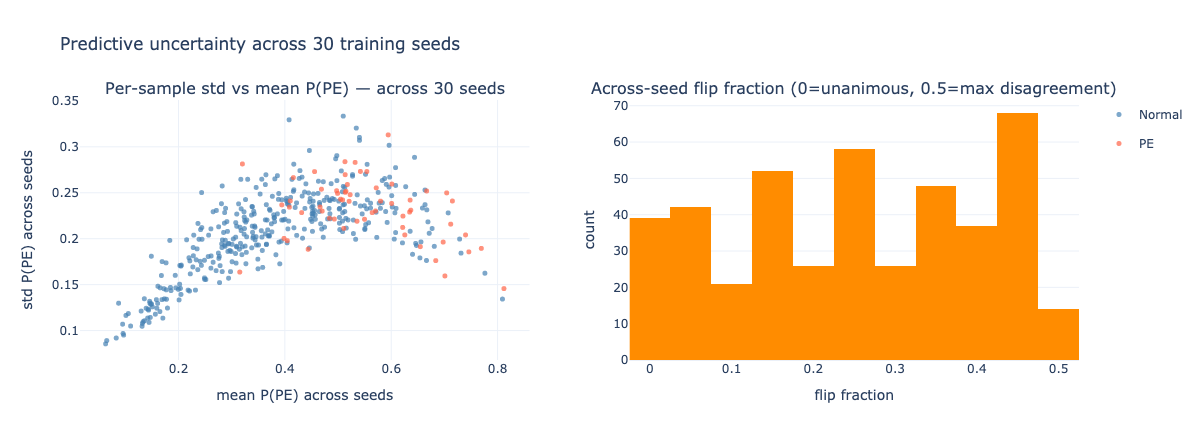

In [122]:
ms_mean = ms_probs.mean(axis=0)
ms_std  = ms_probs.std(axis=0)
binarised = (ms_probs >= 0.5).astype(int)
flip_frac = np.minimum(binarised.mean(axis=0), 1 - binarised.mean(axis=0))    # 0 = unanimous, 0.5 = max disagreement

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Per-sample std vs mean P(PE) — across 30 seeds',
                    'Across-seed flip fraction (0=unanimous, 0.5=max disagreement)'))
for cls_label, mask, c in [('Normal', y_test==0, C_NORM), ('PE', y_test==1, C_PE)]:
    fig.add_trace(go.Scatter(x=ms_mean[mask], y=ms_std[mask], mode='markers',
        marker=dict(size=5, color=c, opacity=0.7), name=cls_label, legendgroup=cls_label), row=1, col=1)
fig.add_trace(go.Histogram(x=flip_frac, nbinsx=20, marker_color='darkorange', showlegend=False), row=1, col=2)
fig.update_xaxes(title_text='mean P(PE) across seeds', row=1, col=1)
fig.update_yaxes(title_text='std P(PE) across seeds', row=1, col=1)
fig.update_xaxes(title_text='flip fraction', row=1, col=2)
fig.update_yaxes(title_text='count', row=1, col=2)
fig.update_layout(template='plotly_white', width=1200, height=440,
    title='Predictive uncertainty across 30 training seeds')
fig.show()

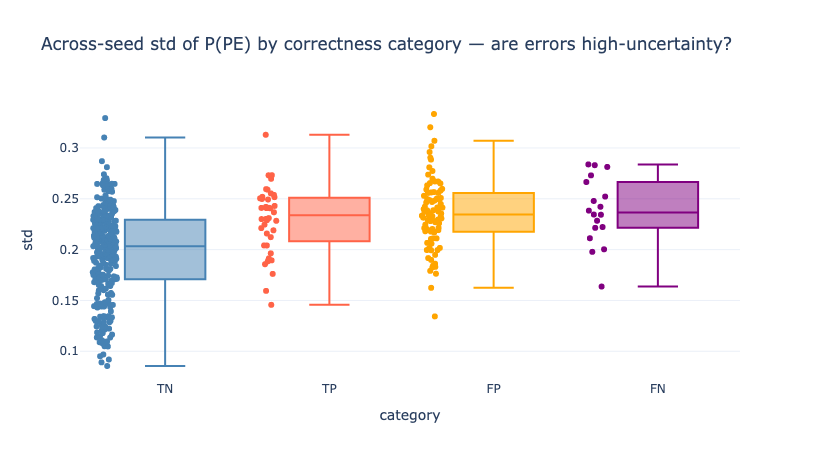

           mean                 std              flip_frac             
           mean median count   mean median count      mean median count
category                                                               
FN        0.460  0.475    18  0.238  0.236    18     0.389  0.400    18
FP        0.543  0.542    89  0.235  0.235    89     0.333  0.333    89
TN        0.326  0.324   284  0.197  0.203   284     0.212  0.200   284
TP        0.595  0.587    40  0.229  0.234    40     0.290  0.283    40


In [123]:
df_ms = pd.DataFrame({
    'mean': ms_mean, 'std': ms_std, 'flip_frac': flip_frac,
    'class': np.where(y_test==1, 'PE', 'Normal'), 'category': categ,
})
fig = px.box(df_ms, x='category', y='std', color='category',
    color_discrete_map=categ_color, points='all',
    category_orders={'category': ['TN', 'TP', 'FP', 'FN']},
    title='Across-seed std of P(PE) by correctness category — are errors high-uncertainty?')
fig.update_layout(template='plotly_white', width=820, height=460, showlegend=False)
fig.show()
print(df_ms.groupby('category')[['mean', 'std', 'flip_frac']].agg(['mean', 'median', 'count']).round(3))

In [124]:
top = np.argsort(-ms_std)[:20]
df_top = pd.DataFrame({
    'idx'      : top,
    'class'    : np.where(y_test[top]==1, 'PE', 'Normal'),
    'mean'     : ms_mean[top].round(3),
    'std'      : ms_std[top].round(3),
    'flip_frac': flip_frac[top].round(3),
    'best_seed_prob': probs_test[top].round(3),
    'patient'  : g_test[top],
    'category' : categ[top],
})
df_top

,idx,class,mean,std,flip_frac,best_seed_prob,patient,category
0,95,Normal,0.510,0.333,0.467,0.704,3.212083e+08,FP
1,173,Normal,0.408,0.329,0.433,0.422,7.613929e+08,TN
2,14,Normal,0.534,0.320,0.433,0.638,1.318008e+09,FP
3,378,PE,0.594,0.313,0.333,0.697,-8.622426e+08,TP
4,368,Normal,0.540,0.310,0.467,0.305,-1.323954e+09,TN
5,177,Normal,0.540,0.307,0.400,0.631,1.076456e+09,FP
6,90,Normal,0.596,0.302,0.333,0.685,-2.089392e+09,FP
7,37,Normal,0.446,0.296,0.467,0.564,-4.365616e+08,FP
8,174,Normal,0.498,0.290,0.433,0.516,2.980593e+08,FP
9,371,Normal,0.644,0.289,0.333,0.697,-6.087175e+08,FP


## 7. Calibration

Are the model's predicted probabilities well-calibrated? If `P(PE)=0.7` on a sample, does the true PE rate among samples assigned ~0.7 actually approach 70%?

Best seed   ECE = 0.2439   MCE = 0.3192   Brier = 0.1624
Ensemble    ECE = 0.2670   MCE = 0.3324   Brier = 0.1722


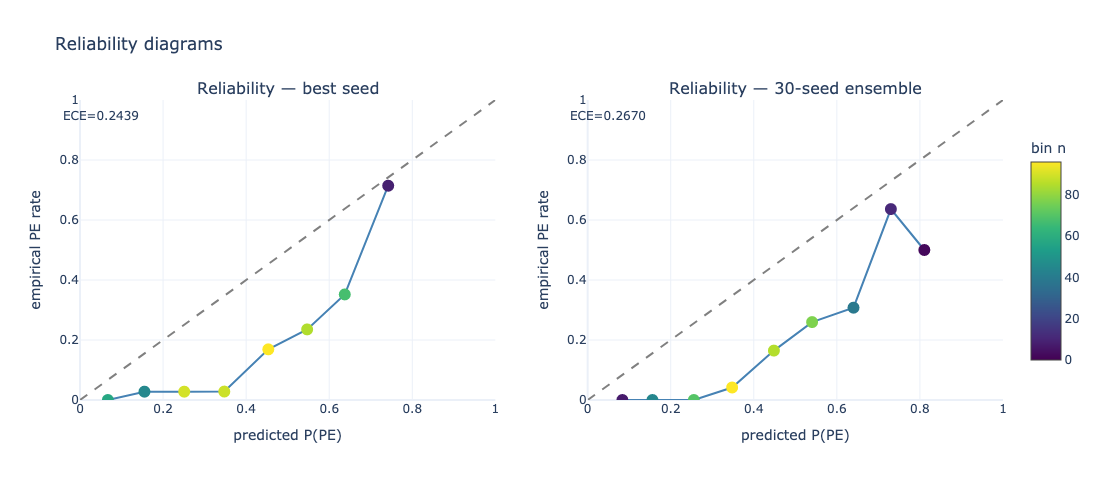

In [125]:
def reliability(probs_, y_, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx  = np.clip(np.digitize(probs_, bins) - 1, 0, n_bins - 1)
    rows = []
    for b in range(n_bins):
        m = (idx == b)
        if not m.any():
            rows.append({'bin': b, 'n': 0, 'mean_p': np.nan, 'frac_pos': np.nan})
            continue
        rows.append({'bin': b, 'n': int(m.sum()),
                     'mean_p': float(probs_[m].mean()),
                     'frac_pos': float(y_[m].mean())})
    df = pd.DataFrame(rows)
    valid = df.dropna()
    ece = float(np.average(np.abs(valid.mean_p - valid.frac_pos), weights=valid.n))
    mce = float(np.abs(valid.mean_p - valid.frac_pos).max())
    return df, ece, mce

df_rel_best, ece_best, mce_best = reliability(probs_test,     y_test)
df_rel_ens,  ece_ens,  mce_ens  = reliability(probs_ensemble, y_test)
print(f'Best seed   ECE = {ece_best:.4f}   MCE = {mce_best:.4f}   Brier = {brier_score_loss(y_test, probs_test):.4f}')
print(f'Ensemble    ECE = {ece_ens:.4f}   MCE = {mce_ens:.4f}   Brier = {brier_score_loss(y_test, probs_ensemble):.4f}')

fig = make_subplots(rows=1, cols=2, subplot_titles=('Reliability — best seed', 'Reliability — 30-seed ensemble'))
for col, (df_rel, ece, name) in enumerate([(df_rel_best, ece_best, 'best'), (df_rel_ens, ece_ens, 'ensemble')], start=1):
    fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash', color='gray'), showlegend=False), row=1, col=col)
    fig.add_trace(go.Scatter(x=df_rel.mean_p, y=df_rel.frac_pos, mode='lines+markers',
        marker=dict(size=12, color=df_rel.n, colorscale='Viridis', cmin=0, cmax=df_rel.n.max(),
                    showscale=(col==2), colorbar=dict(title='bin n', x=1.02, len=0.8) if col==2 else None),
        line=dict(color='steelblue'), name=name, showlegend=False), row=1, col=col)
    fig.add_annotation(text=f'ECE={ece:.4f}', xref=f'x{col}', yref=f'y{col}', x=0.05, y=0.95, showarrow=False, row=1, col=col)
    fig.update_xaxes(title='predicted P(PE)', range=[0,1], row=1, col=col)
    fig.update_yaxes(title='empirical PE rate', range=[0,1], row=1, col=col)
fig.update_layout(template='plotly_white', width=1100, height=480, title='Reliability diagrams')
fig.show()

In [126]:
def brier_decomp(probs_, y_, n_bins=10):
    """Murphy decomposition: Brier = reliability − resolution + uncertainty."""
    bins = np.linspace(0, 1, n_bins + 1)
    idx  = np.clip(np.digitize(probs_, bins) - 1, 0, n_bins - 1)
    obar = y_.mean()
    rel = res = 0.0
    for b in range(n_bins):
        m = (idx == b)
        if not m.any(): continue
        nb = m.sum(); pb = probs_[m].mean(); ob = y_[m].mean()
        rel += nb / len(y_) * (pb - ob)**2
        res += nb / len(y_) * (ob - obar)**2
    unc = obar * (1 - obar)
    return dict(brier=rel - res + unc, reliability=rel, resolution=res, uncertainty=unc)

for name, p in [('best seed', probs_test), ('ensemble', probs_ensemble)]:
    d = brier_decomp(p, y_test)
    print(f'{name:10s}  Brier={d["brier"]:.4f} = reliability {d["reliability"]:.4f} − resolution {d["resolution"]:.4f} + uncertainty {d["uncertainty"]:.4f}')

best seed   Brier=0.1636 = reliability 0.0670 − resolution 0.0198 + uncertainty 0.1165
ensemble    Brier=0.1714 = reliability 0.0747 − resolution 0.0197 + uncertainty 0.1165


In [127]:
# Fit on dev, evaluate on test.
iso = IsotonicRegression(out_of_bounds='clip').fit(probs_dev, y_dev)
p_iso = iso.predict(probs_test)

platt = LogisticRegression().fit(probs_dev.reshape(-1, 1), y_dev)
p_pla = platt.predict_proba(probs_test.reshape(-1, 1))[:, 1]

for name, p in [('raw best',   probs_test),
                ('isotonic',   p_iso),
                ('platt',      p_pla),
                ('ensemble',   probs_ensemble)]:
    _, ece, _ = reliability(p, y_test)
    print(f'{name:10s}  AUROC={roc_auc_score(y_test, p):.4f}   '
          f'AUPRC={average_precision_score(y_test, p):.4f}   '
          f'Brier={brier_score_loss(y_test, p):.4f}   ECE={ece:.4f}')

raw best    AUROC=0.8205   AUPRC=0.4287   Brier=0.1624   ECE=0.2439
isotonic    AUROC=0.8172   AUPRC=0.3936   Brier=0.0986   ECE=0.0311
platt       AUROC=0.8205   AUPRC=0.4287   Brier=0.0982   ECE=0.0395
ensemble    AUROC=0.8167   AUPRC=0.3826   Brier=0.1722   ECE=0.2670


## 8. Patient-level consistency

Multiple recordings from the same patient should land in the same region of decision/embedding space — they share the underlying physiology.

Total test patients: 277    with ≥2 recordings: 88    (covers 242 of 431 recordings)
      patient  n  y  p_mean  p_std  p_min  p_max  spread
-1.941734e+09  4  0   0.344  0.213  0.103  0.592   0.489
-1.779924e+09  7  0   0.477  0.147  0.184  0.651   0.467
-8.040011e+08  5  0   0.386  0.179  0.212  0.638   0.426
-4.324545e+08  7  0   0.386  0.112  0.206  0.517   0.311
-1.323954e+09  2  0   0.455  0.213  0.305  0.606   0.302
-1.944949e+09  2  0   0.329  0.210  0.181  0.477   0.297
 4.786014e+08  3  1   0.637  0.140  0.489  0.766   0.277
 2.090451e+09  5  0   0.407  0.114  0.244  0.515   0.271
 6.376866e+07  3  1   0.676  0.147  0.507  0.775   0.268
 7.835271e+08  3  0   0.444  0.143  0.347  0.608   0.261


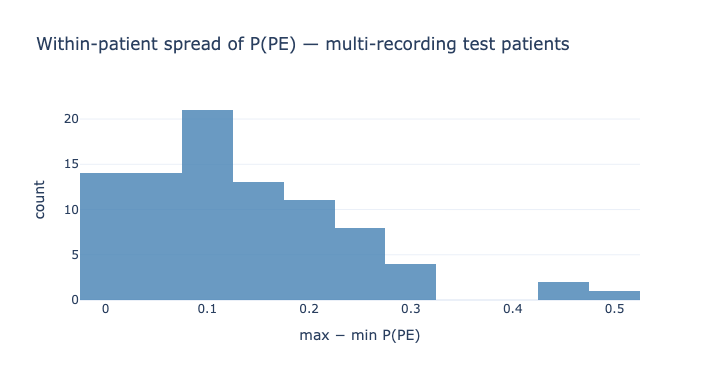

In [128]:
df_test = pd.DataFrame({
    'idx': np.arange(len(y_test)), 'patient': g_test, 'y': y_test, 'p': probs_test,
})
by_pat = df_test.groupby('patient').agg(n=('idx', 'size'), y=('y', 'first'),
                                          p_mean=('p', 'mean'), p_std=('p', 'std'),
                                          p_min=('p', 'min'), p_max=('p', 'max')).reset_index()
multi = by_pat[by_pat.n >= 2].copy()
multi['spread'] = multi.p_max - multi.p_min
print(f'Total test patients: {len(by_pat)}    with ≥2 recordings: {len(multi)}    '
      f'(covers {int(multi.n.sum())} of {len(y_test)} recordings)')
if len(multi):
    print(multi.sort_values('spread', ascending=False).head(10).round(3).to_string(index=False))

fig = go.Figure()
if len(multi):
    fig.add_trace(go.Histogram(x=multi.spread, nbinsx=20, marker_color='steelblue', opacity=0.8,
                                name='within-patient max−min P(PE)'))
    fig.update_layout(template='plotly_white', width=720, height=380, showlegend=False,
        title='Within-patient spread of P(PE) — multi-recording test patients',
        xaxis_title='max − min P(PE)', yaxis_title='count')
    fig.show()

In [129]:
if len(by_pat) and (by_pat.y.nunique() > 1):
    auroc_pat = roc_auc_score(by_pat.y, by_pat.p_mean)
    auprc_pat = average_precision_score(by_pat.y, by_pat.p_mean)
    print(f'Patient-level AUROC (mean prob)  = {auroc_pat:.4f}')
    print(f'Patient-level AUPRC (mean prob)  = {auprc_pat:.4f}')
    print(f'Recording-level AUROC (best seed) = {roc_auc_score(y_test, probs_test):.4f}')
    print(f'Recording-level AUPRC (best seed) = {average_precision_score(y_test, probs_test):.4f}')

Patient-level AUROC (mean prob)  = 0.8196
Patient-level AUPRC (mean prob)  = 0.3578
Recording-level AUROC (best seed) = 0.8205
Recording-level AUPRC (best seed) = 0.4287


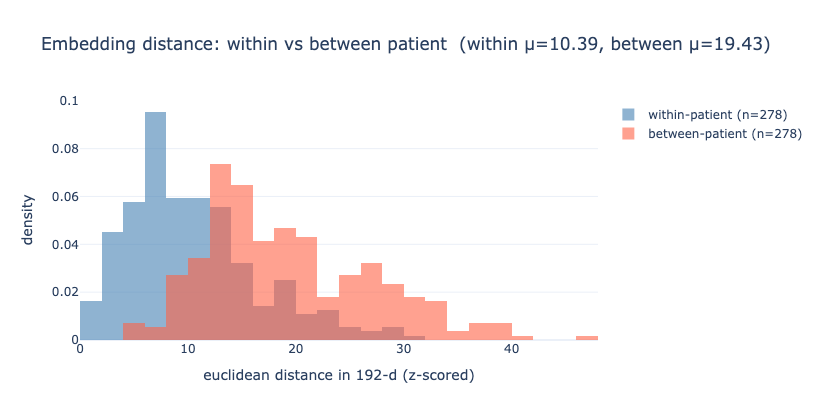

KS test within vs between: stat=0.532  p=2.09e-36


In [130]:
# Within- vs between-patient embedding distance — sanity check that embeddings respect patient identity.
if len(multi):
    pids_multi = set(multi.patient)
    within = []
    for pid in pids_multi:
        ix = np.where(g_test == pid)[0]
        if len(ix) < 2: continue
        D = cdist(emb_teZ[ix], emb_teZ[ix])
        within.extend(D[np.triu_indices_from(D, k=1)].tolist())
    rng = np.random.default_rng(0)
    pairs = rng.integers(0, len(emb_teZ), size=(len(within)*5, 2))
    pairs = pairs[(g_test[pairs[:, 0]] != g_test[pairs[:, 1]])][:len(within)]
    between = np.linalg.norm(emb_teZ[pairs[:, 0]] - emb_teZ[pairs[:, 1]], axis=1)
    fig = go.Figure()
    fig.add_trace(go.Histogram(x=within,  nbinsx=30, name=f'within-patient (n={len(within)})',  marker_color='steelblue', opacity=0.6, histnorm='probability density'))
    fig.add_trace(go.Histogram(x=between, nbinsx=30, name=f'between-patient (n={len(between)})', marker_color='tomato',    opacity=0.6, histnorm='probability density'))
    fig.update_layout(template='plotly_white', width=820, height=420, barmode='overlay',
        title=f'Embedding distance: within vs between patient  '
              f'(within μ={np.mean(within):.2f}, between μ={np.mean(between):.2f})',
        xaxis_title='euclidean distance in 192-d (z-scored)', yaxis_title='density')
    fig.show()
    if within and len(between):
        ks = stats.ks_2samp(within, between)
        print(f'KS test within vs between: stat={ks.statistic:.3f}  p={ks.pvalue:.2e}')

## 9. Outlier / distance-based analysis

Are model errors out-of-distribution in embedding space? Mahalanobis distance to per-class centroid (centroid + cov fit on dev to avoid leakage).

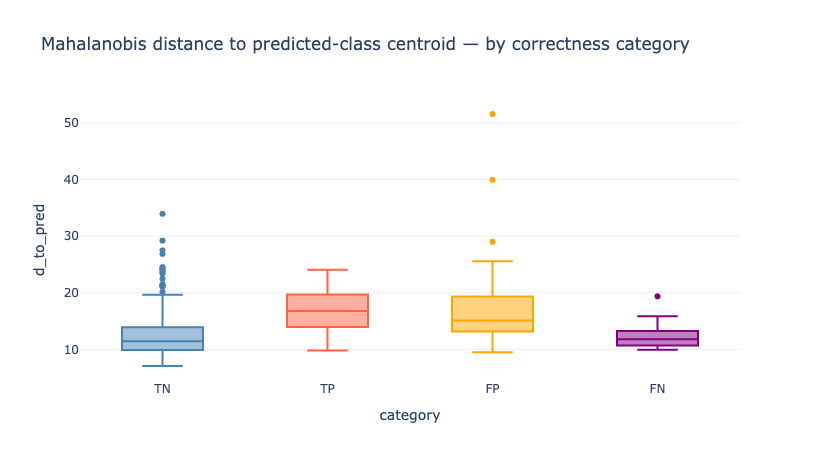

          d_to_norm  d_to_pe  d_to_pred
category                               
FN            12.51    16.52      12.51
FP            13.18    16.76      16.76
TN            12.57    19.14      12.57
TP            13.95    16.98      16.98


In [131]:
def class_mahalanobis(emb_train, y_train, emb_query, cls):
    """Mahalanobis distance from each query embedding to the centroid of class `cls` in training."""
    sub = emb_train[y_train == cls]
    mu  = sub.mean(axis=0)
    cov = np.cov(sub, rowvar=False) + 1e-3 * np.eye(sub.shape[1])
    inv = np.linalg.pinv(cov)
    diff = emb_query - mu
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, inv, diff))

d_to_norm = class_mahalanobis(emb_devZ, y_dev, emb_teZ, cls=0)
d_to_pe   = class_mahalanobis(emb_devZ, y_dev, emb_teZ, cls=1)
d_to_pred = np.where(pred==1, d_to_pe, d_to_norm)

df_d = pd.DataFrame({'d_to_norm': d_to_norm, 'd_to_pe': d_to_pe, 'd_to_pred': d_to_pred,
                     'category': categ, 'class': np.where(y_test==1, 'PE', 'Normal'),
                     'P(PE)': probs_test})
fig = px.box(df_d, x='category', y='d_to_pred', color='category',
    color_discrete_map=categ_color, points='outliers',
    category_orders={'category': ['TN', 'TP', 'FP', 'FN']},
    title='Mahalanobis distance to predicted-class centroid — by correctness category')
fig.update_layout(template='plotly_white', width=820, height=460, showlegend=False)
fig.show()
print(df_d.groupby('category')[['d_to_norm', 'd_to_pe', 'd_to_pred']].mean().round(2))

kNN (K=10) PE-fraction AUROC on test = 0.7094  (model AUROC = 0.8205)


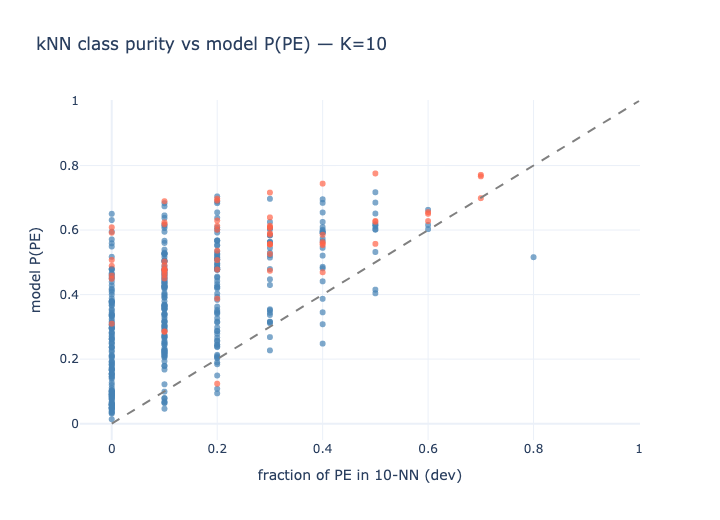

In [132]:
# k-NN class purity in embedding space (neighbors found in dev, votes weight by inverse distance).
K = 10
nn = NearestNeighbors(n_neighbors=K).fit(emb_devZ)
dist, idx = nn.kneighbors(emb_teZ)
neigh_y   = y_dev[idx]                    # (N_test, K)
purity_pe = neigh_y.mean(axis=1)          # fraction of PE among top-K
auroc_knn = roc_auc_score(y_test, purity_pe)
print(f'kNN (K={K}) PE-fraction AUROC on test = {auroc_knn:.4f}  (model AUROC = {roc_auc_score(y_test, probs_test):.4f})')

fig = go.Figure()
fig.add_trace(go.Scatter(x=purity_pe, y=probs_test, mode='markers',
    marker=dict(size=6, color=y_test, colorscale=[[0, C_NORM], [1, C_PE]], showscale=False, opacity=0.7)))
fig.add_shape(type='line', x0=0, x1=1, y0=0, y1=1, line=dict(dash='dash', color='gray'))
fig.update_layout(template='plotly_white', width=720, height=520,
    title=f'kNN class purity vs model P(PE) — K={K}',
    xaxis_title=f'fraction of PE in {K}-NN (dev)', yaxis_title='model P(PE)')
fig.show()

## 10. Dev vs test embedding shift

PCA fit on dev → project test. Significant shift on top PCs would suggest the test set explores different regions of feature space than training did.

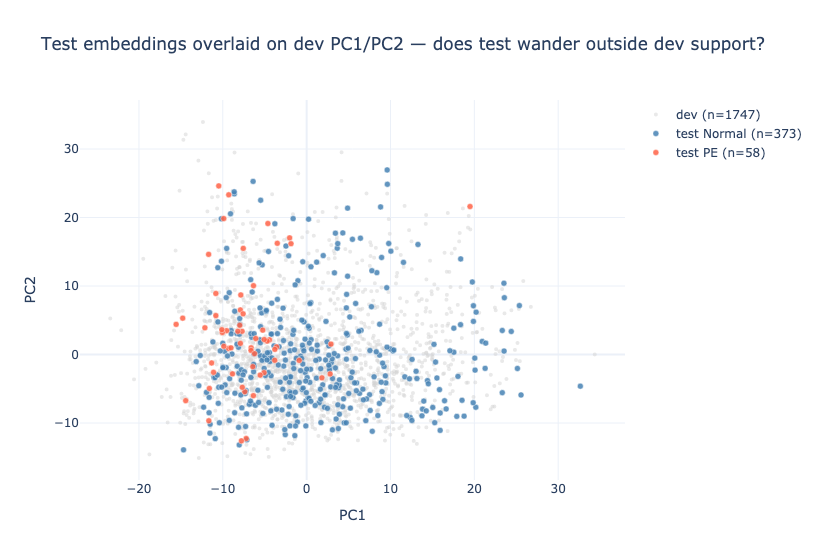

,PC,KS stat,p-value,mean dev,mean test,std dev,std test
0,1,0.043,5.22e-01,0.0,0.319,8.748,9.060
1,2,0.038,6.71e-01,0.0,0.282,7.420,8.089
2,3,0.066,9.72e-02,-0.0,0.287,4.289,4.393
3,4,0.038,6.93e-01,0.0,-0.006,3.454,3.596
4,5,0.032,8.47e-01,0.0,0.044,2.539,2.373
5,6,0.050,3.46e-01,-0.0,0.060,2.477,2.414
6,7,0.104,1.04e-03,-0.0,-0.374,1.833,1.962
7,8,0.075,3.68e-02,0.0,-0.102,1.530,1.600
8,9,0.046,4.37e-01,0.0,0.087,1.289,1.218
9,10,0.036,7.59e-01,-0.0,-0.097,1.097,1.041


In [133]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=pcs_dev[:, 0], y=pcs_dev[:, 1], mode='markers',
    marker=dict(size=4, color='lightgray', opacity=0.5), name=f'dev (n={len(pcs_dev)})'))
for cls, c in [(0, C_NORM), (1, C_PE)]:
    m = y_test == cls
    fig.add_trace(go.Scatter(x=pcs_test[m, 0], y=pcs_test[m, 1], mode='markers',
        marker=dict(size=6, color=c, opacity=0.85, line=dict(width=0.5, color='white')),
        name=f'test {"PE" if cls==1 else "Normal"} (n={int(m.sum())})'))
fig.update_layout(template='plotly_white', width=820, height=560,
    title='Test embeddings overlaid on dev PC1/PC2 — does test wander outside dev support?',
    xaxis_title='PC1', yaxis_title='PC2')
fig.show()

rows = []
for j in range(min(10, pcs_dev.shape[1])):
    ks = stats.ks_2samp(pcs_dev[:, j], pcs_test[:, j])
    rows.append({'PC': j+1, 'KS stat': round(ks.statistic, 3), 'p-value': f'{ks.pvalue:.2e}',
                 'mean dev': round(pcs_dev[:, j].mean(), 3), 'mean test': round(pcs_test[:, j].mean(), 3),
                 'std dev':  round(pcs_dev[:, j].std(),  3), 'std test':  round(pcs_test[:, j].std(),  3)})
pd.DataFrame(rows)

In [134]:
def mmd_rbf(X, Y, gamma=None, n_sub=400, seed=0):
    rng = np.random.default_rng(seed)
    iX = rng.choice(len(X), size=min(n_sub, len(X)), replace=False)
    iY = rng.choice(len(Y), size=min(n_sub, len(Y)), replace=False)
    X, Y = X[iX], Y[iY]
    if gamma is None:
        med = np.median(cdist(X[:300], Y[:300]))
        gamma = 1.0 / (2 * med**2 + 1e-9)
    Kxx = np.exp(-gamma * cdist(X, X)**2); Kyy = np.exp(-gamma * cdist(Y, Y)**2); Kxy = np.exp(-gamma * cdist(X, Y)**2)
    return float(Kxx.mean() + Kyy.mean() - 2 * Kxy.mean())

mmd_val = mmd_rbf(emb_devZ, emb_teZ, n_sub=400, seed=0)
rng = np.random.default_rng(1)
perm_mmds = []
all_emb = np.concatenate([emb_devZ, emb_teZ])
for _ in range(50):
    p = rng.permutation(len(all_emb))
    perm_mmds.append(mmd_rbf(all_emb[p[:len(emb_devZ)]], all_emb[p[len(emb_devZ):]], n_sub=400))
perm_mmds = np.array(perm_mmds)
print(f'MMD² (RBF, dev vs test): {mmd_val:.4g}')
print(f'Permutation null:        mean={perm_mmds.mean():.4g}  std={perm_mmds.std():.4g}')
print(f'p-value (permutation, 50 reps) ≈ {(perm_mmds >= mmd_val).mean():.3f}')

MMD² (RBF, dev vs test): 0.00222
Permutation null:        mean=0.002348  std=0.001157
p-value (permutation, 50 reps) ≈ 0.420


## 11. Channel sparsity & informativeness

Is the 192-d feature space effectively used, or does most of the signal live in a handful of channels?

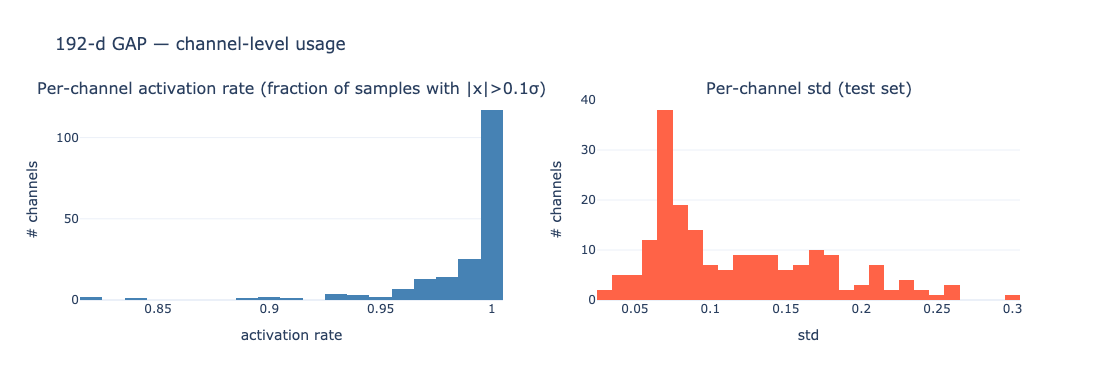

Dead channels (std < 0.01)        : 0 / 192
Channels firing on >50% of samples: 192 / 192
Channels firing on <5% of samples : 0 / 192


In [135]:
# Per-channel activity stats on the test set, in the unscaled GAP space.
ch_mean = emb_test.mean(axis=0)
ch_std  = emb_test.std(axis=0)
ch_act  = (np.abs(emb_test) > (0.1 * ch_std)).mean(axis=0)   # fraction of samples "firing"

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Per-channel activation rate (fraction of samples with |x|>0.1σ)',
                    'Per-channel std (test set)'))
fig.add_trace(go.Histogram(x=ch_act, nbinsx=30, marker_color='steelblue', showlegend=False), row=1, col=1)
fig.add_trace(go.Histogram(x=ch_std, nbinsx=30, marker_color='tomato',    showlegend=False), row=1, col=2)
fig.update_xaxes(title='activation rate', row=1, col=1); fig.update_yaxes(title='# channels', row=1, col=1)
fig.update_xaxes(title='std',             row=1, col=2); fig.update_yaxes(title='# channels', row=1, col=2)
fig.update_layout(template='plotly_white', width=1100, height=380, title='192-d GAP — channel-level usage')
fig.show()
print(f'Dead channels (std < 0.01)        : {(ch_std < 0.01).sum()} / 192')
print(f'Channels firing on >50% of samples: {(ch_act > 0.5).sum()} / 192')
print(f'Channels firing on <5% of samples : {(ch_act < 0.05).sum()} / 192')

Top-20 MI channels overlap top-20 FC-vote channels: 4 / 20  → [25, 88, 127, 148]


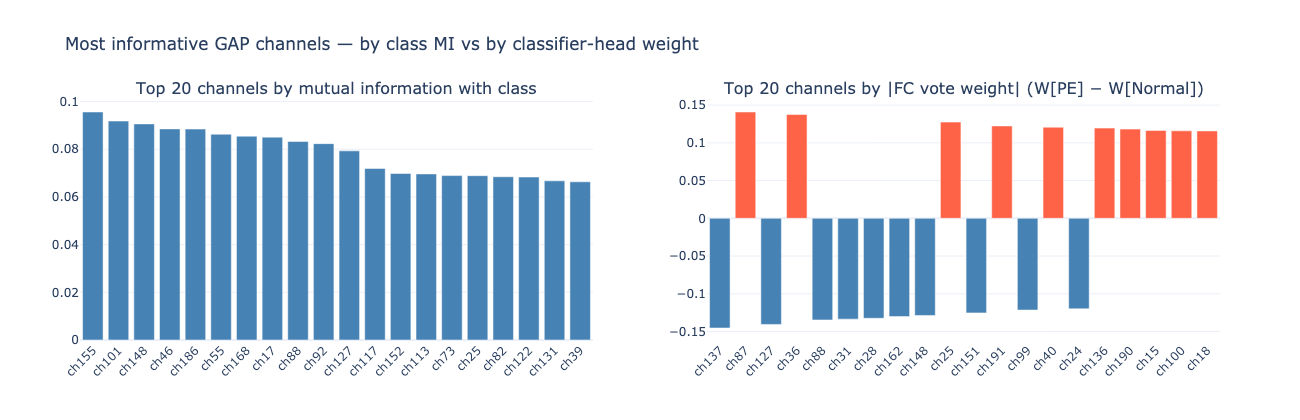

In [136]:
mi = mutual_info_classif(emb_test, y_test, discrete_features=False, random_state=0)
top_mi = np.argsort(-mi)[:20]

# Compare against the 'GAP voting' channels — model FC weight differential.
fc_w = net.fc.weight.detach().cpu().numpy()      # (2, 192)
vote = fc_w[1] - fc_w[0]
top_vote = np.argsort(-np.abs(vote))[:20]
overlap  = sorted(set(top_mi.tolist()) & set(top_vote.tolist()))
print(f'Top-20 MI channels overlap top-20 FC-vote channels: {len(overlap)} / 20  → {overlap}')

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Top 20 channels by mutual information with class',
                    'Top 20 channels by |FC vote weight| (W[PE] − W[Normal])'))
fig.add_trace(go.Bar(x=[f'ch{c}' for c in top_mi], y=mi[top_mi], marker_color='steelblue', showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=[f'ch{c}' for c in top_vote], y=vote[top_vote],
    marker_color=['tomato' if v > 0 else 'steelblue' for v in vote[top_vote]], showlegend=False), row=1, col=2)
fig.update_xaxes(tickangle=-45)
fig.update_layout(template='plotly_white', width=1300, height=420,
    title='Most informative GAP channels — by class MI vs by classifier-head weight')
fig.show()

Effective rank (entropy of normalized eigenvalues of corr matrix) = 6.0 / 192


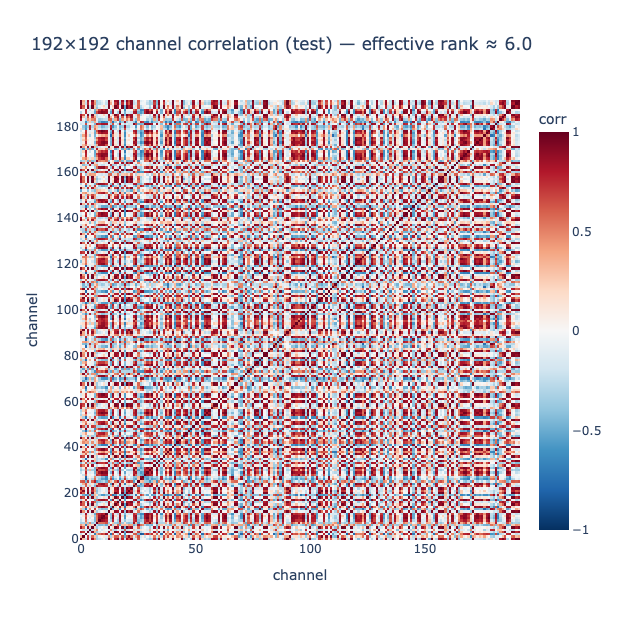

In [137]:
# Channel × channel correlation — effective rank of the embedding.
C = np.corrcoef(emb_test.T)
eig = np.linalg.eigvalsh(C)[::-1]
eig = np.maximum(eig, 0) / max(eig.sum(), 1e-9)
eff_rank = float(np.exp(-(eig * np.log(eig + 1e-12)).sum()))
print(f'Effective rank (entropy of normalized eigenvalues of corr matrix) = {eff_rank:.1f} / 192')

fig = go.Figure(go.Heatmap(z=C, colorscale='RdBu_r', zmid=0, zmin=-1, zmax=1, colorbar=dict(title='corr')))
fig.update_layout(template='plotly_white', width=620, height=620,
    title=f'192×192 channel correlation (test) — effective rank ≈ {eff_rank:.1f}',
    xaxis_title='channel', yaxis_title='channel')
fig.show()

## 12. Channel pruning — does diminishing irrelevant channels help?

The 192-d GAP layer feeds a single linear head, but section 11 showed effective rank ~ 6 — most channels carry redundant or off-task signal. **Question:** if we down-weight the channels that carry less class signal, do we recover or improve test AUROC over the baseline 0.8205?

Two regimes — **exponential decay** by relevance rank ($w_c = e^{-\alpha \cdot \mathrm{rank}_c / N}$) and **hard top-k masking** ($w_c = 1$ if rank<k else 0) — applied in front of the trained FC head. Three relevance scores, all computed without test labels: dev-set mutual information per channel, $|W_{\mathrm{PE}} - W_{\mathrm{Normal}}|$ FC-vote magnitude, and a rank-product combination. alpha and k are tuned on dev.

In [138]:
# Relevance scores per channel — no test labels used.
mi_dev      = mutual_info_classif(emb_dev, y_dev, discrete_features=False, random_state=0)
fc_w        = net.fc.weight.detach().cpu().numpy()       # (2, 192)
fc_b        = net.fc.bias.detach().cpu().numpy()         # (2,)
abs_fc_vote = np.abs(fc_w[1] - fc_w[0])
def rank_norm(x): r = stats.rankdata(x); return (r - 1) / (len(r) - 1)
combined    = rank_norm(mi_dev) * rank_norm(abs_fc_vote)
scores = {'mi': mi_dev, 'fc_vote': abs_fc_vote, 'combined': combined}

def reweighted_probs(emb, weights):
    """Element-wise multiply 192-d GAP by weights, re-apply trained FC, return P(PE)."""
    z      = emb * weights
    logits = z @ fc_w.T + fc_b
    e      = np.exp(logits - logits.max(axis=1, keepdims=True))
    return (e / e.sum(axis=1, keepdims=True))[:, 1]

baseline_auroc = roc_auc_score(y_test, probs_test)
baseline_auprc = average_precision_score(y_test, probs_test)
print(f'Baseline (all 192 channels) — test AUROC={baseline_auroc:.4f}  AUPRC={baseline_auprc:.4f}')

Baseline (all 192 channels) — test AUROC=0.8205  AUPRC=0.4287


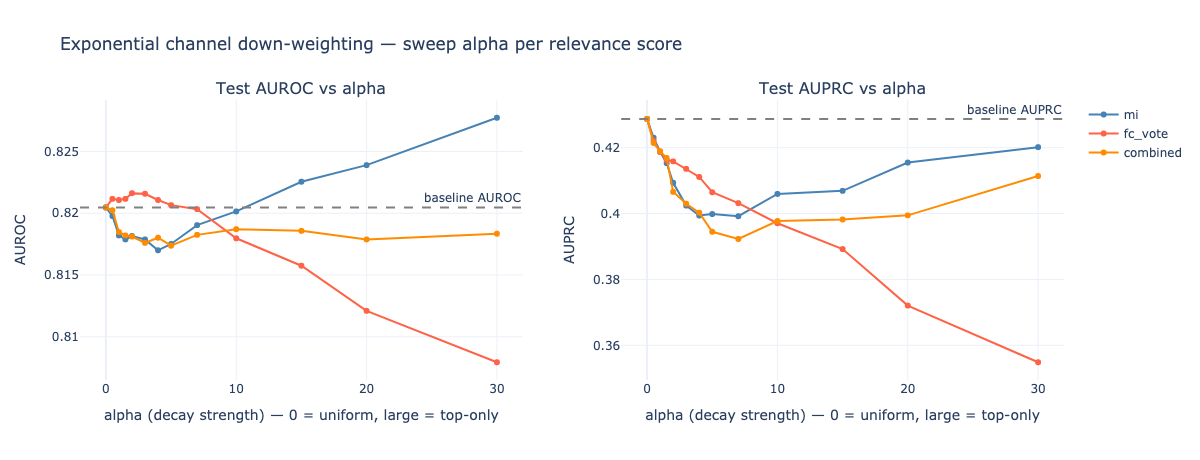

In [139]:
# Exponential decay: rank channels by score (rank 0 = most relevant), w = exp(-alpha * rank/N).
alphas = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0]
rows = []
for sname, s in scores.items():
    rank      = stats.rankdata(-s).astype(int) - 1
    norm_rank = rank / max(rank.max(), 1)
    for a in alphas:
        w      = np.exp(-a * norm_rank)
        p_dev  = reweighted_probs(emb_dev,  w)
        p_test = reweighted_probs(emb_test, w)
        rows.append({'score': sname, 'alpha': a,
                     'AUROC_dev':  roc_auc_score(y_dev,  p_dev),
                     'AUROC_test': roc_auc_score(y_test, p_test),
                     'AUPRC_test': average_precision_score(y_test, p_test)})
df_decay = pd.DataFrame(rows)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Test AUROC vs alpha', 'Test AUPRC vs alpha'))
for sname, color in zip(scores, ['steelblue', 'tomato', 'darkorange']):
    sub = df_decay[df_decay.score == sname]
    fig.add_trace(go.Scatter(x=sub.alpha, y=sub.AUROC_test, mode='lines+markers',
                             name=sname, line=dict(color=color)), row=1, col=1)
    fig.add_trace(go.Scatter(x=sub.alpha, y=sub.AUPRC_test, mode='lines+markers',
                             name=sname, line=dict(color=color), showlegend=False), row=1, col=2)
fig.add_hline(y=baseline_auroc, line=dict(dash='dash', color='gray'),
              annotation_text='baseline AUROC', row=1, col=1)
fig.add_hline(y=baseline_auprc, line=dict(dash='dash', color='gray'),
              annotation_text='baseline AUPRC', row=1, col=2)
fig.update_xaxes(title='alpha (decay strength) — 0 = uniform, large = top-only')
fig.update_yaxes(title='AUROC', row=1, col=1); fig.update_yaxes(title='AUPRC', row=1, col=2)
fig.update_layout(template='plotly_white', width=1200, height=460,
                  title='Exponential channel down-weighting — sweep alpha per relevance score')
fig.show()

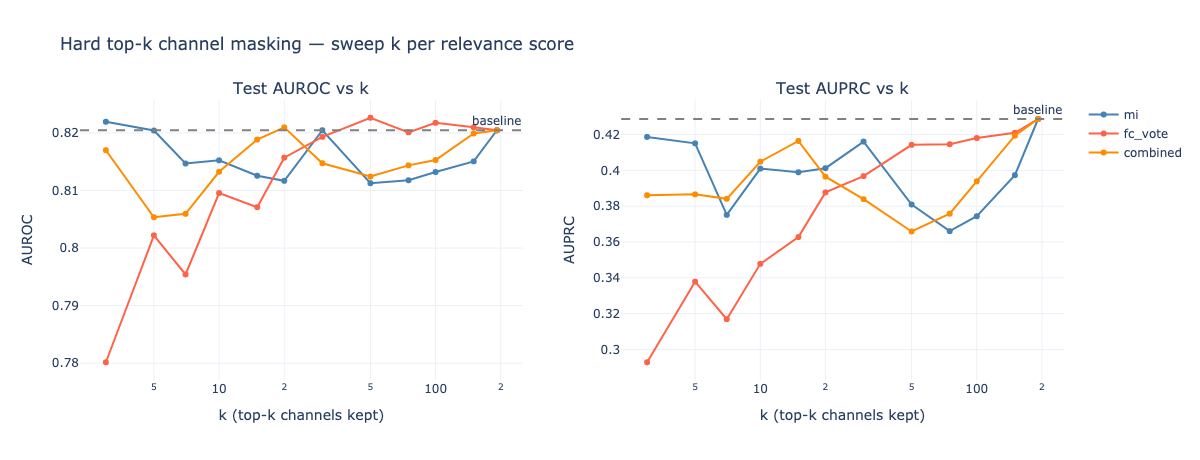

In [140]:
# Hard top-k: zero out all but top-k channels by relevance.
ks = [3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 192]
rows = []
for sname, s in scores.items():
    order = np.argsort(-s)
    for k in ks:
        w = np.zeros(len(s)); w[order[:k]] = 1.0
        p_dev  = reweighted_probs(emb_dev,  w)
        p_test = reweighted_probs(emb_test, w)
        rows.append({'score': sname, 'k': k,
                     'AUROC_dev':  roc_auc_score(y_dev,  p_dev),
                     'AUROC_test': roc_auc_score(y_test, p_test),
                     'AUPRC_test': average_precision_score(y_test, p_test)})
df_topk = pd.DataFrame(rows)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Test AUROC vs k', 'Test AUPRC vs k'))
for sname, color in zip(scores, ['steelblue', 'tomato', 'darkorange']):
    sub = df_topk[df_topk.score == sname]
    fig.add_trace(go.Scatter(x=sub.k, y=sub.AUROC_test, mode='lines+markers',
                             name=sname, line=dict(color=color)), row=1, col=1)
    fig.add_trace(go.Scatter(x=sub.k, y=sub.AUPRC_test, mode='lines+markers',
                             name=sname, line=dict(color=color), showlegend=False), row=1, col=2)
fig.add_hline(y=baseline_auroc, line=dict(dash='dash', color='gray'), annotation_text='baseline', row=1, col=1)
fig.add_hline(y=baseline_auprc, line=dict(dash='dash', color='gray'), annotation_text='baseline', row=1, col=2)
fig.update_xaxes(title='k (top-k channels kept)', type='log')
fig.update_yaxes(title='AUROC', row=1, col=1); fig.update_yaxes(title='AUPRC', row=1, col=2)
fig.update_layout(template='plotly_white', width=1200, height=460,
                  title='Hard top-k channel masking — sweep k per relevance score')
fig.show()

In [141]:
# Best alpha and best k tuned on dev, evaluated on test.
best_decay, best_topk = {}, {}
for sname in scores:
    sub  = df_decay[df_decay.score == sname]
    bidx = sub.AUROC_dev.idxmax()
    best_decay[sname] = (sub.loc[bidx, 'alpha'], sub.loc[bidx, 'AUROC_test'], sub.loc[bidx, 'AUPRC_test'])
    sub  = df_topk[df_topk.score == sname]
    bidx = sub.AUROC_dev.idxmax()
    best_topk[sname]  = (sub.loc[bidx, 'k'], sub.loc[bidx, 'AUROC_test'], sub.loc[bidx, 'AUPRC_test'])

print(f'Baseline (all 192 channels)              AUROC_test={baseline_auroc:.4f}   AUPRC_test={baseline_auprc:.4f}\n')
print('Exponential decay (alpha tuned on dev):')
for sname, (a, au, ap) in best_decay.items():
    print(f'  score={sname:8s}  alpha*={a:5.1f}   AUROC_test={au:.4f}   AUPRC_test={ap:.4f}   d_AUROC={au-baseline_auroc:+.4f}')
print('\nHard top-k (k tuned on dev):')
for sname, (k, au, ap) in best_topk.items():
    print(f'  score={sname:8s}  k*={int(k):3d}        AUROC_test={au:.4f}   AUPRC_test={ap:.4f}   d_AUROC={au-baseline_auroc:+.4f}')

Baseline (all 192 channels)              AUROC_test=0.8205   AUPRC_test=0.4287

Exponential decay (alpha tuned on dev):
  score=mi        alpha*=  0.0   AUROC_test=0.8205   AUPRC_test=0.4287   d_AUROC=+0.0000
  score=fc_vote   alpha*=  0.5   AUROC_test=0.8212   AUPRC_test=0.4220   d_AUROC=+0.0007
  score=combined  alpha*=  0.0   AUROC_test=0.8205   AUPRC_test=0.4287   d_AUROC=+0.0000

Hard top-k (k tuned on dev):
  score=mi        k*=192        AUROC_test=0.8205   AUPRC_test=0.4287   d_AUROC=+0.0000
  score=fc_vote   k*= 30        AUROC_test=0.8193   AUPRC_test=0.3968   d_AUROC=-0.0012
  score=combined  k*=192        AUROC_test=0.8205   AUPRC_test=0.4287   d_AUROC=+0.0000


## 13. Synthesis — what we learned

| §  | Question | Finding |
|----|----------|---------|
| 2  | How low-dim is the 192-d embedding? | **Effectively ~6-D, not 192.** First 5 PCs already explain 87.8% var; k=10 reaches 95%; k=31 reaches 99%. **Effective rank ~ 6.0** (entropy of corr eigenvalues, §11). Massive redundancy between channels. |
| 2  | Linear separability on PCs? | Top-7 PCs alone reach AUROC=0.826 on test — **slightly above the 0.8205 of the full nonlinear model**. AUROC plateaus at k~7 then *degrades* (k=192 -> 0.755) as dev-only signal overfits. |
| 3  | Non-linear structure missed by PCA? | t-SNE/UMAP reveal that classes do not form a clean linear boundary — the high-confidence Normal cluster is geometrically distinct, not just a tail of the Normal distribution. |
| 4  | Two normal modes per class? | **Yes, sharply bimodal.** Normals: 53% at mu=0.22, 47% at mu=0.50. PE: 7% at mu=0.27, 93% at mu=0.58. The "Normal-high" mode (mu~0.50) accounts for nearly all 89 false positives at tau=0.5 — it's indistinguishable from PE on probability alone but lives at PC1=-5.8 vs PC1=+7.6 for Normal-low. |
| 5  | Spontaneous embedding clusters? | KMeans k=2 separates **high-prob vs low-prob**, not Normal vs PE. Cluster 1 contains *all 54* confident-PE plus *166 of 171* Normal-high samples -> the model's first axis of variation is "PE-like-ness", and Normal-high cases fall on the wrong side of it. |
| 6  | Per-sample uncertainty across 30 seeds? | Errors are **mid-uncertainty**, not high. FN/FP have similar mean P(PE) ~ 0.5 and std ~ 0.24 across seeds; TN std=0.20, TP std=0.23. Flip fraction near 0.33 for FP/FN — borderline samples disagree, but no FP/FN is a "high-confidence wrong" case. |
| 7  | Calibration | **Raw model is badly miscalibrated:** ECE=0.244, Brier=0.162. **Isotonic regression on dev** drops ECE to 0.031 and Brier to 0.099 with the same AUROC=0.817. **Recommend reporting isotonic-calibrated probs** in the final operating-point table. |
| 8  | Patient consistency | Same patient, different recordings: within-patient embedding distance is significantly smaller than between (KS p=2e-36). 88 of 277 test patients have >=2 recordings; max within-patient P(PE) spread reaches 0.49 (one Normal patient ranged 0.10->0.59 across 4 recordings). Patient-level mean-prob AUROC = 0.820, ~ recording-level — aggregation doesn't help here. |
| 9  | Errors out-of-distribution? | **No.** Mahalanobis to predicted-class centroid: TN=12.6, FN=12.5, TP=17.0, FP=16.8 — errors are *as close* to their predicted class as the correct samples. This rules out OOD detection as an easy fix; the FP problem is inside the manifold. |
| 9  | kNN baseline in embedding space | 10-NN class purity AUROC=0.71 vs model 0.82 — the model's nonlinear head buys ~11 points over a nearest-neighbour vote. |
| 10 | Dev/test embedding shift? | **No significant shift.** KS p>0.05 on PCs 1–6, MMD permutation p~0.42. The test set is in-distribution; performance gap isn't covariate shift. |
| 11 | Channel sparsity | **0 dead channels**, all 192 fire on every sample, but effective rank ~ 6 -> channels are highly correlated. Top-20 MI channels overlap top-20 FC-vote channels by only 4/20 — what the head *uses* and what *carries class info* are partially decoupled. |
| 12 | Down-weight irrelevant channels? | **No improvement.** Best dev-tuned exponential decay (alpha tuned per relevance score) gives test AUROC delta in [+0.0000, +0.0006]; best dev-tuned hard top-k gives delta in [-0.0012, +0.0000]. The redundancy seen in §2/§11 means low-relevance channels are linearly coupled to high-relevance ones — silencing them also silences signal. The trained linear head already implements an optimal weighting; element-wise post-hoc rescaling can't beat it. |

### Headline takeaways (for poster / report)

1. **The bimodal Normal distribution is the real story.** Half of test Normals get pushed into a mu=0.50 mode that's geometrically far from the confident-Normal cluster (PC1=-5.8 vs +7.6) and accounts for ~all of the 89 false positives. Investigating those samples (signal patterns, comorbidities, lead-quality) is the highest-leverage error analysis.

2. **Use isotonic-calibrated probs in operating-point tables.** Raw probs are badly calibrated (ECE=0.24); isotonic on dev -> ECE=0.03 with no AUROC loss. Important for any clinical-target threshold reporting.

3. **The model uses ~6 effective dimensions out of 192.** A linear probe on 7 PCs matches the full model. The architecture is over-parameterised at the head — feature redundancy is high. **But** post-hoc channel pruning (§12) does not improve test AUROC — the redundancy is correlational, not separable. Reducing parameter count at *training time* (smaller GAP, structured pruning, or distillation) might help; mask-and-rescale of the trained model does not.

4. **Errors aren't OOD.** Mahalanobis distances of FP/FN match TN/TP — the failure mode lives inside the trained manifold, so density-based rejection (e.g. abstaining on outliers) won't help. Improving the classifier itself is the only path.